In [1]:
#makemore part5开启！

In [2]:
#我们之前已经很大程度上优化了我们的神经网络
#但是我们的loss最低最低只能降到2左右
#这主要是因为我们的上下文就3个字符
#太小了，理论上我们很难实现很低的loss
#所以这一章我们来优化它
#上一章我们主要内容是手动推导backward，可以算是dlc支线任务
#现在我们回归主线，从part3导入初始化代码

In [3]:
import torch
import torch.nn.functional as F
import random
import matplotlib.pyplot as plt
%matplotlib inline

words=open("../names.txt","r").read().splitlines()

chars=sorted(list(set(''.join(words))))
stoi={s:i+1 for i,s in enumerate(chars)}
stoi['.']=0
itos={i:s for s,i in stoi.items()}
vocab_size=len(itos)

def build_dataset(words,block_size):
  X, Y = [], []
  for w in words:

    context = [0] * block_size
    for ch in w + '.':
      ix = stoi[ch]
      X.append(context)
      Y.append(ix)  
      context = context[1:] + [ix] 

  X = torch.tensor(X)
  Y = torch.tensor(Y)
  return X, Y

random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

block_size=3

Xtr, Ytr = build_dataset(words[:n1],block_size)
Xdev, Ydev = build_dataset(words[n1:n2],block_size)
Xte, Yte = build_dataset(words[n2:],block_size)

In [4]:
#因为我们已经理解了神经网络的基本底层逻辑
#所以我们现在直接操作类就好了
class Linear:
    def __init__(self, fan_in, fan_out, bias=True): 
        self.weight = torch.randn((fan_in, fan_out)) / fan_in ** 0.5
        self.bias = torch.zeros(fan_out) if bias else None

    def __call__(self, x):
        self.out = x @ self.weight               
        if self.bias is not None:
            self.out += self.bias
        return self.out

    def parameters(self):
        return [self.weight] + ([] if self.bias is None else [self.bias])


class BatchNorm1d:
    def __init__(self, dim, eps=1e-5, momentum=0.1):

        self.eps = eps
        self.momentum = momentum
        self.training = True                  

        self.gamma = torch.ones(dim)   
        self.beta = torch.zeros(dim)        

        self.running_mean = torch.zeros(dim)      
        self.running_var = torch.ones(dim)           

    def __call__(self, x):
        if self.training:
            xmean = x.mean(0, keepdim=True)      
            xvar = x.var(0, keepdim=True)          
        else:
            xmean = self.running_mean          
            xvar = self.running_var
        xhat = (x - xmean) / torch.sqrt(xvar + self.eps) 
        self.out = self.gamma * xhat + self.beta

        if self.training:
            with torch.no_grad():
                self.running_mean = (1 - self.momentum) * self.running_mean + self.momentum * xmean
                self.running_var = (1 - self.momentum) * self.running_var + self.momentum * xvar
        return self.out

    def parameters(self):
        return [self.gamma, self.beta]


class Tanh:
    def __call__(self, x):
        self.out = torch.tanh(x)
        return self.out

    def parameters(self):
        return []

In [5]:
#我们之前一直使用g作为随机数生成器
#其实torch本身可以实现全局的固定种子
torch.manual_seed(42);

In [6]:
n_embd=10
n_hidden=200

C=torch.randn((vocab_size,n_embd))
layers=[
    Linear(n_embd*block_size,n_hidden,bias=False),BatchNorm1d(n_hidden),Tanh(),
    Linear(n_hidden,vocab_size),
]

with torch.no_grad():
    layers[-1].weight*=0.1

parameters=[C]+[p for layer in layers for p in layer.parameters()]
print("总参数量：",sum(p.nelement() for p in parameters))
for p in parameters:
    p.requires_grad=True

总参数量： 12097


In [7]:
max_steps=200000
batch_size=32
lossi=[]

for i in range(max_steps):

    #batch
    ix = torch.randint(0,Xtr.shape[0],(batch_size,))
    Xb,Yb=Xtr[ix],Ytr[ix]

    #前向传播
    emb=C[Xb]
    x=emb.view(emb.shape[0],-1)
    for layer in layers:
        x=layer(x)
    loss=F.cross_entropy(x,Yb)

    #让每一层的out的grad保留下来
    for layer in layers:
        layer.out.retain_grad()

    #清空梯度
    for p in parameters:
        p.grad=None

    #反向传播
    loss.backward()

    #更新
    lr = 0.1 if i < max_steps/2 else 0.01
    for p in parameters:
        p.data += -lr * p.grad

    if i%10000==0:
        print(f"当前轮次:{i:7d}/总轮次:{max_steps:7d} loss={loss.item():.4f}")

    lossi.append(loss.log10().item())

当前轮次:      0/总轮次: 200000 loss=3.2966
当前轮次:  10000/总轮次: 200000 loss=2.2322
当前轮次:  20000/总轮次: 200000 loss=2.4111
当前轮次:  30000/总轮次: 200000 loss=2.1004
当前轮次:  40000/总轮次: 200000 loss=2.3157
当前轮次:  50000/总轮次: 200000 loss=2.2104
当前轮次:  60000/总轮次: 200000 loss=1.9653
当前轮次:  70000/总轮次: 200000 loss=1.9767
当前轮次:  80000/总轮次: 200000 loss=2.6738
当前轮次:  90000/总轮次: 200000 loss=2.0837
当前轮次: 100000/总轮次: 200000 loss=2.2730
当前轮次: 110000/总轮次: 200000 loss=1.7087
当前轮次: 120000/总轮次: 200000 loss=2.3243
当前轮次: 130000/总轮次: 200000 loss=2.2512
当前轮次: 140000/总轮次: 200000 loss=2.0113
当前轮次: 150000/总轮次: 200000 loss=1.8195
当前轮次: 160000/总轮次: 200000 loss=1.7985
当前轮次: 170000/总轮次: 200000 loss=2.2206
当前轮次: 180000/总轮次: 200000 loss=2.0566
当前轮次: 190000/总轮次: 200000 loss=2.1030


In [8]:
for layer in layers:
    layer.training=False

train 2.0621414184570312
val 2.109346389770508


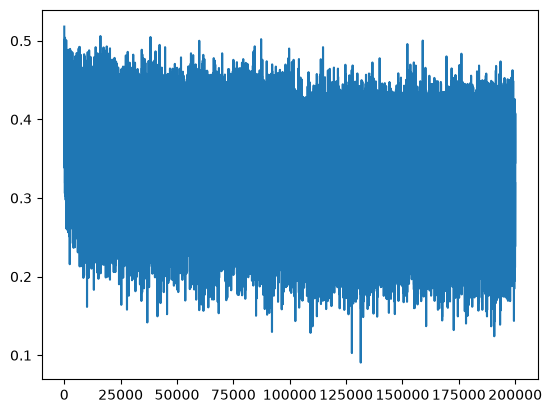

In [9]:
@torch.no_grad()
def split_loss(split):
    x,y = {
        'train': (Xtr, Ytr),
        'val': (Xdev, Ydev),
        'test': (Xte, Yte),
    }[split]

    emb = C[x]
    x = emb.view(emb.shape[0], -1)
    for layer in layers:
        x = layer(x)
    loss = F.cross_entropy(x, y)

    print(split, loss.item())

split_loss('train')
split_loss('val')

plt.plot(lossi)

In [10]:
#生成姓名
for i in range(20):
    context = [0] * block_size
    out = []
    while True:
        emb = C[torch.tensor([context])]
        x = emb.view(emb.shape[0], -1)
        for layer in layers:
            x = layer(x)
        probs = F.softmax(x, dim=1)
        ix = torch.multinomial(
            probs,
            num_samples=1
        ).item()
        context = context[1:] + [ix]
        out.append(itos[ix])
        if ix == 0:
            break

    print(''.join(out))

ivon.
fanili.
thoommasamiel.
emmadery.
andr.
aleigh.
kelynnie.
jazul.
carleen.
jah.
jorra.
alaya.
shonan.
vishylaharia.
juna.
vio.
orven.
meriell.
laiye.
zefina.


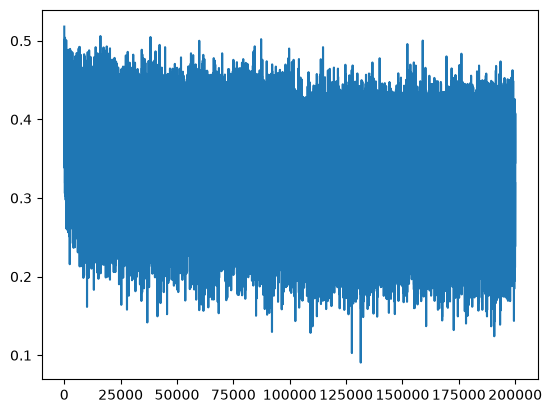

In [11]:
#接下来我们就要来优化我们的模型
#首先我们先来优化一下我们的图片
plt.plot(lossi)

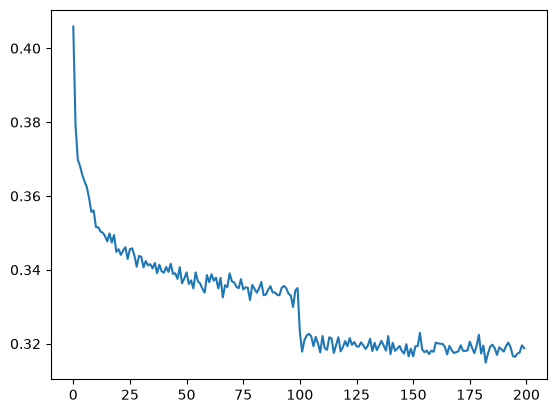

In [12]:
#这张图片反映不了任何信息，可以说就是一坨蓝色色块
#我们分片段取平均
plt.plot(torch.tensor(lossi).view(-1,1000).mean(1))

In [13]:
#这样就能看出其实我们的模型进步明显，只不过之前的图太密集了
#中间还有一道很明显的下降是学习率的降低，让我们的模型可以稳定的下降

In [14]:
#接下来我们来优化下前向传播
# emb=C[Xb]
# x=emb.view(emb.shape[0],-1)
# for layer in layers:
#     x=layer(x)
# loss=F.cross_entropy(x,Yb)
#这段代码实在是冗余，我们的C没有被并入layers，还有一个view的环节，不好看不好看

In [15]:
class Embedding:

  def __init__(self, num_embeddings, embedding_dim):
    self.weight = torch.randn((num_embeddings, embedding_dim))

  def __call__(self, IX):
    self.out = self.weight[IX]
    return self.out

  def parameters(self):
    return [self.weight]


class Flatten:

  def __call__(self, x):
    self.out = x.view(x.shape[0], -1)
    return self.out

  def parameters(self):
    return []

In [16]:
#我们实现两个新的类，这样可以把他们给塞到layers里了
#而且这两个类也是在pytorch中有现成的实现，我们只是套用过来了

In [17]:
n_embd=10
n_hidden=200

layers=[
    Embedding(vocab_size,n_embd),Flatten(),
    Linear(n_embd*block_size,n_hidden,bias=False),BatchNorm1d(n_hidden),Tanh(),
    Linear(n_hidden,vocab_size),
]

with torch.no_grad():
    layers[-1].weight*=0.1

parameters=[p for layer in layers for p in layer.parameters()]
print("总参数量：",sum(p.nelement() for p in parameters))
for p in parameters:
    p.requires_grad=True

max_steps=200000
batch_size=32
lossi=[]

for i in range(max_steps):

    #batch
    ix = torch.randint(0,Xtr.shape[0],(batch_size,))
    Xb,Yb=Xtr[ix],Ytr[ix]

    #前向传播
    x=Xb
    for layer in layers:
        x=layer(x)
    loss=F.cross_entropy(x,Yb)

    #让每一层的out的grad保留下来
    for layer in layers:
        layer.out.retain_grad()

    #清空梯度
    for p in parameters:
        p.grad=None

    #反向传播
    loss.backward()

    #更新
    lr = 0.1 if i < max_steps/2 else 0.01
    for p in parameters:
        p.data += -lr * p.grad

    if i%10000==0:
        print(f"当前轮次:{i:7d}/总轮次:{max_steps:7d} loss={loss.item():.4f}")

    lossi.append(loss.log10().item())

    if i>=1000:
        break

总参数量： 12097
当前轮次:      0/总轮次: 200000 loss=3.2763


In [18]:
#冒烟就行

In [19]:
#其实pytorch也实现了一个叫做container的东西
#这个东西的功能就和我们建立的layers是一样的，依次调用层
#而且我们的parameters功能也可以集成到这个里

In [20]:
class Sequential:
    def __init__(self,layers):
        self.layers=layers
        
    def __call__(self,x):      
        for layer in self.layers:
            x=layer(x)
        self.out=x
        return self.out

    def parameters(self):
        return[p for layer in self.layers for p in layer.parameters()]

In [21]:
n_embd=10
n_hidden=200

layers=[
    Embedding(vocab_size,n_embd),Flatten(),
    Linear(n_embd*block_size,n_hidden,bias=False),BatchNorm1d(n_hidden),Tanh(),
    Linear(n_hidden,vocab_size),
]

with torch.no_grad():
    layers[-1].weight*=0.1

model=Sequential(layers)

parameters=model.parameters()
print("总参数量：",sum(p.nelement() for p in parameters))
for p in parameters:
    p.requires_grad=True

max_steps=200000
batch_size=32
lossi=[]

for i in range(max_steps):

    #batch
    ix = torch.randint(0,Xtr.shape[0],(batch_size,))
    Xb,Yb=Xtr[ix],Ytr[ix]

    #前向传播
    logits=model(Xb)
    loss=F.cross_entropy(logits,Yb)

    #让每一层的out的grad保留下来
    for layer in layers:
        layer.out.retain_grad()

    #清空梯度
    for p in parameters:
        p.grad=None

    #反向传播
    loss.backward()

    #更新
    lr = 0.1 if i < max_steps/2 else 0.01
    for p in parameters:
        p.data += -lr * p.grad

    if i%10000==0:
        print(f"当前轮次:{i:7d}/总轮次:{max_steps:7d} loss={loss.item():.4f}")

    lossi.append(loss.log10().item())

总参数量： 12097
当前轮次:      0/总轮次: 200000 loss=3.3080
当前轮次:  10000/总轮次: 200000 loss=2.0364
当前轮次:  20000/总轮次: 200000 loss=1.7232
当前轮次:  30000/总轮次: 200000 loss=2.1280
当前轮次:  40000/总轮次: 200000 loss=2.2789
当前轮次:  50000/总轮次: 200000 loss=2.0853
当前轮次:  60000/总轮次: 200000 loss=1.9882
当前轮次:  70000/总轮次: 200000 loss=2.3663
当前轮次:  80000/总轮次: 200000 loss=2.3452
当前轮次:  90000/总轮次: 200000 loss=2.1122
当前轮次: 100000/总轮次: 200000 loss=2.3031
当前轮次: 110000/总轮次: 200000 loss=2.4456
当前轮次: 120000/总轮次: 200000 loss=1.8437
当前轮次: 130000/总轮次: 200000 loss=2.3020
当前轮次: 140000/总轮次: 200000 loss=2.2269
当前轮次: 150000/总轮次: 200000 loss=2.1884
当前轮次: 160000/总轮次: 200000 loss=2.3422
当前轮次: 170000/总轮次: 200000 loss=2.2684
当前轮次: 180000/总轮次: 200000 loss=1.9245
当前轮次: 190000/总轮次: 200000 loss=1.8849


In [22]:
#更简洁了
#而且我们的验证和采样代码也可以简洁

In [23]:
for layer in model.layers:
    layer.training=False

In [24]:
@torch.no_grad()
def split_loss(split):
    x,y = {
        'train': (Xtr, Ytr),
        'val': (Xdev, Ydev),
        'test': (Xte, Yte),
    }[split]

    logits=model(x)
    loss = F.cross_entropy(logits, y)

    print(split, loss.item())

split_loss('train')
split_loss('val')

train 2.064502239227295
val 2.107546091079712


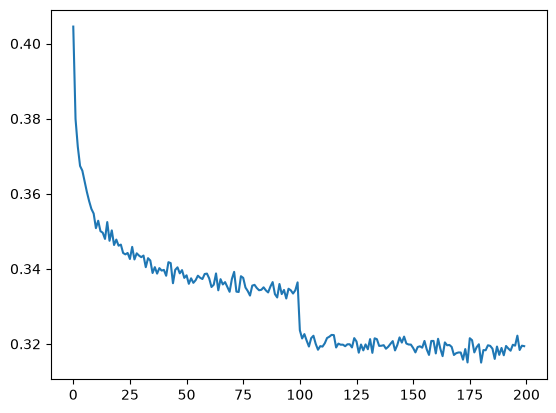

In [25]:
plt.plot(torch.tensor(lossi).view(-1,1000).mean(1))

In [26]:
#生成姓名
for i in range(20):
    context = [0] * block_size
    out = []
    while True:
        logits=model(torch.tensor([context]))
        probs = F.softmax(logits, dim=1)
        ix = torch.multinomial(
            probs,
            num_samples=1
        ).item()
        context = context[1:] + [ix]
        out.append(itos[ix])
        if ix == 0:
            break

    print(''.join(out))

diel.
colen.
die.
line.
turi.
jaxy.
milory.
mondonstry.
kie.
chan.
nemhantleigh.
luna.
fina.
eriannia.
naj.
leth.
alea.
jaxxyn.
ashn.
bree.


In [27]:
#好的，代码优化部分做完了，我们现在要来优化模型了
#首先我们虽然用embedding实现了字符的向量化，但是我们的做法很直接
#而且我们其实很早就强调过：我们的上下文太短了
#所以现在我们使用这篇2016年deepmind提出的方法

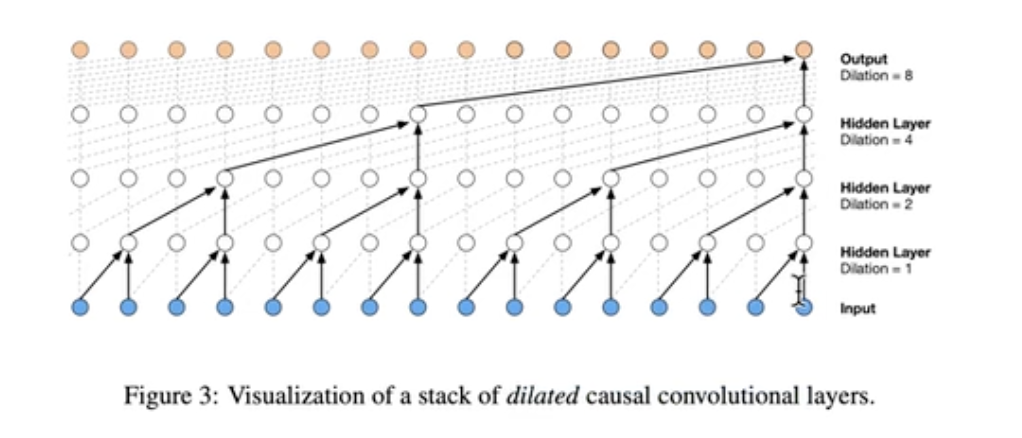

In [28]:
#我们两个两个的去压缩我们的字符，实现输入上下文的扩展

In [29]:
block_size=8

Xtr, Ytr = build_dataset(words[:n1],block_size)
Xdev, Ydev = build_dataset(words[n1:n2],block_size)
Xte, Yte = build_dataset(words[n2:],block_size)

In [30]:
n_embd=10
n_hidden=200

layers=[
    Embedding(vocab_size,n_embd),Flatten(),
    Linear(n_embd*block_size,n_hidden,bias=False),BatchNorm1d(n_hidden),Tanh(),
    Linear(n_hidden,vocab_size),
]

with torch.no_grad():
    layers[-1].weight*=0.1

model=Sequential(layers)

parameters=model.parameters()
print("总参数量：",sum(p.nelement() for p in parameters))
for p in parameters:
    p.requires_grad=True

max_steps=200000
batch_size=32
lossi=[]

总参数量： 22097


In [31]:
for i in range(max_steps):

    #batch
    ix = torch.randint(0,Xtr.shape[0],(batch_size,))
    Xb,Yb=Xtr[ix],Ytr[ix]

    #前向传播
    logits=model(Xb)
    loss=F.cross_entropy(logits,Yb)

    #让每一层的out的grad保留下来
    for layer in layers:
        layer.out.retain_grad()

    #清空梯度
    for p in parameters:
        p.grad=None

    #反向传播
    loss.backward()

    #更新
    lr = 0.1 if i < max_steps/2 else 0.01
    for p in parameters:
        p.data += -lr * p.grad

    if i%10000==0:
        print(f"当前轮次:{i:7d}/总轮次:{max_steps:7d} loss={loss.item():.4f}")

    lossi.append(loss.log10().item())

当前轮次:      0/总轮次: 200000 loss=3.2987
当前轮次:  10000/总轮次: 200000 loss=2.3370
当前轮次:  20000/总轮次: 200000 loss=2.0200
当前轮次:  30000/总轮次: 200000 loss=1.8770
当前轮次:  40000/总轮次: 200000 loss=1.9941
当前轮次:  50000/总轮次: 200000 loss=1.8905
当前轮次:  60000/总轮次: 200000 loss=2.4825
当前轮次:  70000/总轮次: 200000 loss=1.5299
当前轮次:  80000/总轮次: 200000 loss=2.2406
当前轮次:  90000/总轮次: 200000 loss=2.1756
当前轮次: 100000/总轮次: 200000 loss=1.7515
当前轮次: 110000/总轮次: 200000 loss=2.1024
当前轮次: 120000/总轮次: 200000 loss=1.9527
当前轮次: 130000/总轮次: 200000 loss=2.2393
当前轮次: 140000/总轮次: 200000 loss=2.1380
当前轮次: 150000/总轮次: 200000 loss=2.0995
当前轮次: 160000/总轮次: 200000 loss=1.8891
当前轮次: 170000/总轮次: 200000 loss=1.9052
当前轮次: 180000/总轮次: 200000 loss=1.6231
当前轮次: 190000/总轮次: 200000 loss=1.8957


train 1.928919792175293
val 2.0323472023010254


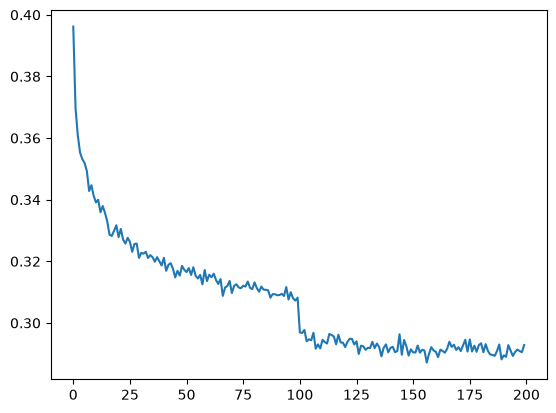

In [32]:
for layer in model.layers:
    layer.training=False
@torch.no_grad()
def split_loss(split):
    x,y = {
        'train': (Xtr, Ytr),
        'val': (Xdev, Ydev),
        'test': (Xte, Yte),
    }[split]

    logits=model(x)
    loss = F.cross_entropy(logits, y)

    print(split, loss.item())

split_loss('train')
split_loss('val')

plt.plot(torch.tensor(lossi).view(-1,1000).mean(1))

In [33]:
#loss确实小了不少
#生成姓名
for i in range(20):
    context = [0] * block_size
    out = []
    while True:
        logits=model(torch.tensor([context]))
        probs = F.softmax(logits, dim=1)
        ix = torch.multinomial(
            probs,
            num_samples=1
        ).item()
        context = context[1:] + [ix]
        out.append(itos[ix])
        if ix == 0:
            break

    print(''.join(out))

amara.
jameek.
rayten.
zavan.
kleiso.
speron.
matai.
loura.
padriel.
cora.
dakisan.
madhael.
aeloina.
chrishey.
mayven.
saegh.
fazim.
kritton.
erink.
azeel.


In [34]:
#看着还行，但是我们的block明明提升了快三倍，loss却只掉了一点
#因为embedding其实是没有上下文意识的
#他并不会去联系上下文
#而且block_size在变大的过程中，我们的神经网络也要随之变大，不然我们的性能其实是跟不上的，模型会丢掉很多数据
#所以我们决定采用新方法
#这里的生成可以作为我们的性能参考

In [35]:
#在这之前我们要知道一件事：pytorch是非常强大的
(torch.randn(10,20)@torch.randn(20,200)).shape

torch.Size([10, 200])

In [36]:
#这个很好理解对吧，但是pytorch的矩阵乘法可以不止于两个维度
(torch.randn(10,50,20)@torch.randn(20,200)).shape

torch.Size([10, 50, 200])

In [37]:
#是不是很神奇？但是这有什么用呢？
ix = torch.randint(0,Xtr.shape[0],(batch_size,))
Xb,Yb=Xtr[ix],Ytr[ix]
logits=model(Xb)
print(Xb.shape)
print(model.layers[0].out.shape)
print(model.layers[1].out.shape)
print(model.layers[2].out.shape)

torch.Size([32, 8])
torch.Size([32, 8, 10])
torch.Size([32, 80])
torch.Size([32, 200])


In [38]:
#我们可以看到，layers[1]->layers[2]经历了从80->200的变化
#也就是
#(32,80)@(80,200)+(1,200)

In [39]:
#这和我们刚才讲的有什么关联呢？
#因为这80其实是8个字符的embedding向量组成的
#但是这次我们的计算不希望他们直接一起算
#(32,4,20)@(20,200)
#这是我们希望实现的

In [40]:
#所以其实这也不难
#我们之前在embedding就实现了一个
print(model.layers[0].out.shape)
print(model.layers[1].out.shape)

torch.Size([32, 8, 10])
torch.Size([32, 80])


In [41]:
#这两步就是转换形状
#现在我们只需要转换的时候不直接消除一个维度就可以了

In [42]:
class FlattenConsecutive:
    def __init__(self,n):
        self.n=n#n是我们想连续处理的元素的数量
    
    def __call__(self, x):
        B,T,C=x.shape#BTC分别是Batch,Time,Channel的意思
        x=x.view(B,T//self.n,C*self.n)
        if x.shape[1]==1:
            x=x.squeeze()#这个函数可以移除张量中大小是1的维度
        self.out = x
        return self.out

    def parameters(self):
        return []

In [43]:
n_embd=10
n_hidden=200

layers=[
    Embedding(vocab_size,n_embd),
    FlattenConsecutive(block_size),#这样写就和之前是一样的
    Linear(n_embd*block_size,n_hidden,bias=False),BatchNorm1d(n_hidden),Tanh(),
    Linear(n_hidden,vocab_size),
]

with torch.no_grad():
    layers[-1].weight*=0.1

model=Sequential(layers)

parameters=model.parameters()
print("总参数量：",sum(p.nelement() for p in parameters))
for p in parameters:
    p.requires_grad=True

总参数量： 22097


In [44]:
ix = torch.randint(0,Xtr.shape[0],(batch_size,))
Xb,Yb=Xtr[ix],Ytr[ix]
logits=model(Xb)
print(Xb.shape)

torch.Size([32, 8])


In [45]:
for layer in model.layers:
    print(layer.__class__.__name__, ':', tuple(layer.out.shape))

Embedding : (32, 8, 10)
FlattenConsecutive : (32, 80)
Linear : (32, 200)
BatchNorm1d : (32, 200)
Tanh : (32, 200)
Linear : (32, 27)


In [46]:
n_embd=10
n_hidden=200

layers=[
    Embedding(vocab_size,n_embd),
    FlattenConsecutive(2),Linear(n_embd*2,n_hidden,bias=False),BatchNorm1d(n_hidden),Tanh(),
    FlattenConsecutive(2),Linear(n_hidden*2,n_hidden,bias=False),BatchNorm1d(n_hidden),Tanh(),
    FlattenConsecutive(2),Linear(n_hidden*2,n_hidden,bias=False),BatchNorm1d(n_hidden),Tanh(),
    Linear(n_hidden,vocab_size),
]

with torch.no_grad():
    layers[-1].weight*=0.1

model=Sequential(layers)

parameters=model.parameters()
print("总参数量：",sum(p.nelement() for p in parameters))
for p in parameters:
    p.requires_grad=True

总参数量： 170897


In [47]:
#这个真正实现了我们所需要的模型
ix = torch.randint(0,Xtr.shape[0],(batch_size,))
Xb,Yb=Xtr[ix],Ytr[ix]
logits=model(Xb)
print("Xb :",tuple(Xb.shape))
for layer in model.layers:
    print(layer.__class__.__name__, ':', tuple(layer.out.shape))

Xb : (32, 8)
Embedding : (32, 8, 10)
FlattenConsecutive : (32, 4, 20)
Linear : (32, 4, 200)
BatchNorm1d : (32, 4, 200)
Tanh : (32, 4, 200)
FlattenConsecutive : (32, 2, 400)
Linear : (32, 2, 200)
BatchNorm1d : (32, 2, 200)
Tanh : (32, 2, 200)
FlattenConsecutive : (32, 400)
Linear : (32, 200)
BatchNorm1d : (32, 200)
Tanh : (32, 200)
Linear : (32, 27)


In [48]:
#这样我们就分成了两个一组，每一组是一个2*10=20的向量

In [49]:
#要注意！现在我们模型的参数量上涨的非常快
#所以我们可以适当的调整一下隐藏层大小然后来测试一下
n_embd=10
n_hidden=68

layers=[
    Embedding(vocab_size,n_embd),
    FlattenConsecutive(2),Linear(n_embd*2,n_hidden,bias=False),BatchNorm1d(n_hidden),Tanh(),
    FlattenConsecutive(2),Linear(n_hidden*2,n_hidden,bias=False),BatchNorm1d(n_hidden),Tanh(),
    FlattenConsecutive(2),Linear(n_hidden*2,n_hidden,bias=False),BatchNorm1d(n_hidden),Tanh(),
    Linear(n_hidden,vocab_size),
]

with torch.no_grad():
    layers[-1].weight*=0.1

model=Sequential(layers)

parameters=model.parameters()
print("总参数量：",sum(p.nelement() for p in parameters))
for p in parameters:
    p.requires_grad=True

总参数量： 22397


In [50]:
#现在我们的参数量和之前的是差不多的
max_steps=200000
batch_size=32
lossi=[]

for i in range(max_steps):

    #batch
    ix = torch.randint(0,Xtr.shape[0],(batch_size,))
    Xb,Yb=Xtr[ix],Ytr[ix]

    #前向传播
    logits=model(Xb)
    loss=F.cross_entropy(logits,Yb)

    #让每一层的out的grad保留下来
    for layer in layers:
        layer.out.retain_grad()

    #清空梯度
    for p in parameters:
        p.grad=None

    #反向传播
    loss.backward()

    #更新
    lr = 0.1 if i < max_steps/2 else 0.01
    for p in parameters:
        p.data += -lr * p.grad

    if i%10000==0:
        print(f"当前轮次:{i:7d}/总轮次:{max_steps:7d} loss={loss.item():.4f}")

    lossi.append(loss.log10().item())

当前轮次:      0/总轮次: 200000 loss=3.3072
当前轮次:  10000/总轮次: 200000 loss=2.2997
当前轮次:  20000/总轮次: 200000 loss=1.8371
当前轮次:  30000/总轮次: 200000 loss=2.6898
当前轮次:  40000/总轮次: 200000 loss=1.5028
当前轮次:  50000/总轮次: 200000 loss=1.8650
当前轮次:  60000/总轮次: 200000 loss=1.8714
当前轮次:  70000/总轮次: 200000 loss=2.3070
当前轮次:  80000/总轮次: 200000 loss=2.3877
当前轮次:  90000/总轮次: 200000 loss=2.3440
当前轮次: 100000/总轮次: 200000 loss=1.9551
当前轮次: 110000/总轮次: 200000 loss=2.0135
当前轮次: 120000/总轮次: 200000 loss=1.9892
当前轮次: 130000/总轮次: 200000 loss=1.9710
当前轮次: 140000/总轮次: 200000 loss=1.8642
当前轮次: 150000/总轮次: 200000 loss=1.5934
当前轮次: 160000/总轮次: 200000 loss=1.5285
当前轮次: 170000/总轮次: 200000 loss=2.1256
当前轮次: 180000/总轮次: 200000 loss=1.6873
当前轮次: 190000/总轮次: 200000 loss=2.1170


train 1.9477201700210571
val 2.0330581665039062


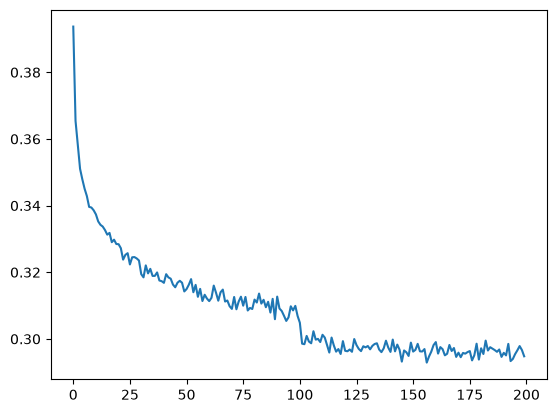

In [51]:
for layer in model.layers:
    layer.training=False
@torch.no_grad()
def split_loss(split):
    x,y = {
        'train': (Xtr, Ytr),
        'val': (Xdev, Ydev),
        'test': (Xte, Yte),
    }[split]

    logits=model(x)
    loss = F.cross_entropy(logits, y)

    print(split, loss.item())

split_loss('train')
split_loss('val')

plt.plot(torch.tensor(lossi).view(-1,1000).mean(1))

In [52]:
#还不错，和之前的单纯的把block_size升到8差不多，但是我们的新架构并没有显著提升

In [53]:
#andrej提出：1.我们没有进行压力测试，没有对神经网络的结构进行优化
#2.我们的batch层可能有问题

In [54]:
# def __call__(self, x):
#     if self.training:
#         xmean = x.mean(0, keepdim=True)      
#         xvar = x.var(0, keepdim=True)          
#     else:
#         xmean = self.running_mean          
#         xvar = self.running_var
#     xhat = (x - xmean) / torch.sqrt(xvar + self.eps) 
#     self.out = self.gamma * xhat + self.beta

#     if self.training:
#         with torch.no_grad():
#             self.running_mean = (1 - self.momentum) * self.running_mean + self.momentum * xmean
#             self.running_var = (1 - self.momentum) * self.running_var + self.momentum * xvar
#     return self.out
#这是batchnorm的代码，我们会发现，求mean和var的时候我们是按照第0个梯度去求的
#但事实上，x已经变成三维的了
ix = torch.randint(0,Xtr.shape[0],(batch_size,))
Xb,Yb=Xtr[ix],Ytr[ix]
logits=model(Xb)
print("Xb :",tuple(Xb.shape))
for layer in model.layers:
    print(layer.__class__.__name__, ':', tuple(layer.out.shape))

Xb : (32, 8)
Embedding : (32, 8, 10)
FlattenConsecutive : (32, 4, 20)
Linear : (32, 4, 68)
BatchNorm1d : (32, 4, 68)
Tanh : (32, 4, 68)
FlattenConsecutive : (32, 2, 136)
Linear : (32, 2, 68)
BatchNorm1d : (32, 2, 68)
Tanh : (32, 2, 68)
FlattenConsecutive : (32, 136)
Linear : (32, 68)
BatchNorm1d : (32, 68)
Tanh : (32, 68)
Linear : (32, 27)


In [55]:
#用e表示batchnorm的过程
e = torch.randn(32, 4, 68)
emean = e.mean(0, keepdim=True) # 1, 4, 68
evar = e.var(0, keepdim=True) # 1, 4, 68
ehat = (e - emean) / torch.sqrt(evar + 1e-5) # 32, 4, 68
print(e.shape,emean.shape,evar.shape,ehat.shape)

torch.Size([32, 4, 68]) torch.Size([1, 4, 68]) torch.Size([1, 4, 68]) torch.Size([32, 4, 68])


In [56]:
#可以看到，其实torch很鸡贼：
#我们说让他在维度0上操作，他直接就不管后面是什么了
#所以我们的这个batchnorm其实是在4*68的维度上工作的
#所以其实：虽然我们分组了，但是batchnorm还是在在单个字符的维度去进行操作的
#也就是说我们希望，把两个字符看成一个整体，但是batchnorm却仍旧一个一个看

In [57]:
#好在torch真的非常强大，mean继承了可以在多个维度上取平均的功能
e = torch.randn(32, 4, 68)
emean = e.mean((0,1), keepdim=True)
evar = e.var((0,1), keepdim=True)
ehat = (e - emean) / torch.sqrt(evar + 1e-5) 
print(e.shape,emean.shape,evar.shape,ehat.shape)

torch.Size([32, 4, 68]) torch.Size([1, 1, 68]) torch.Size([1, 1, 68]) torch.Size([32, 4, 68])


In [58]:
#可以发现，现在我们的0和1维度全部被压缩成0了

In [59]:
class BatchNorm1d:
    def __init__(self, dim, eps=1e-5, momentum=0.1):

        self.eps = eps
        self.momentum = momentum
        self.training = True                  

        self.gamma = torch.ones(dim)   
        self.beta = torch.zeros(dim)        

        self.running_mean = torch.zeros(dim)      
        self.running_var = torch.ones(dim)           

    def __call__(self, x):
        if self.training:#修改逻辑
            if x.ndim==2:                
                dim=0  
            else:
                dim=(0,1)  
            xmean = x.mean(dim, keepdim=True)      
            xvar = x.var(dim, keepdim=True)   
        else:
            xmean = self.running_mean          
            xvar = self.running_var
        xhat = (x - xmean) / torch.sqrt(xvar + self.eps) 
        self.out = self.gamma * xhat + self.beta

        if self.training:
            with torch.no_grad():
                self.running_mean = (1 - self.momentum) * self.running_mean + self.momentum * xmean
                self.running_var = (1 - self.momentum) * self.running_var + self.momentum * xvar
        return self.out

    def parameters(self):
        return [self.gamma, self.beta]

In [60]:
n_embd=10
n_hidden=68

layers=[
    Embedding(vocab_size,n_embd),
    FlattenConsecutive(2),Linear(n_embd*2,n_hidden,bias=False),BatchNorm1d(n_hidden),Tanh(),
    FlattenConsecutive(2),Linear(n_hidden*2,n_hidden,bias=False),BatchNorm1d(n_hidden),Tanh(),
    FlattenConsecutive(2),Linear(n_hidden*2,n_hidden,bias=False),BatchNorm1d(n_hidden),Tanh(),
    Linear(n_hidden,vocab_size),
]

with torch.no_grad():
    layers[-1].weight*=0.1

model=Sequential(layers)

parameters=model.parameters()
print("总参数量：",sum(p.nelement() for p in parameters))
for p in parameters:
    p.requires_grad=True

ix = torch.randint(0,Xtr.shape[0],(batch_size,))
Xb,Yb=Xtr[ix],Ytr[ix]
logits=model(Xb)
print("Xb :",tuple(Xb.shape))
for layer in model.layers:
    print(layer.__class__.__name__, ':', tuple(layer.out.shape))

总参数量： 22397
Xb : (32, 8)
Embedding : (32, 8, 10)
FlattenConsecutive : (32, 4, 20)
Linear : (32, 4, 68)
BatchNorm1d : (32, 4, 68)
Tanh : (32, 4, 68)
FlattenConsecutive : (32, 2, 136)
Linear : (32, 2, 68)
BatchNorm1d : (32, 2, 68)
Tanh : (32, 2, 68)
FlattenConsecutive : (32, 136)
Linear : (32, 68)
BatchNorm1d : (32, 68)
Tanh : (32, 68)
Linear : (32, 27)


In [61]:
#形状还是一样，但是我们可以查看batchnorm的运行内部
model.layers[3].running_mean.shape

torch.Size([1, 1, 68])

In [62]:
#现在的形状是对的了

In [63]:
#重新训练下
max_steps=200000
batch_size=32
lossi=[]

for i in range(max_steps):

    #batch
    ix = torch.randint(0,Xtr.shape[0],(batch_size,))
    Xb,Yb=Xtr[ix],Ytr[ix]

    #前向传播
    logits=model(Xb)
    loss=F.cross_entropy(logits,Yb)

    #让每一层的out的grad保留下来
    for layer in layers:
        layer.out.retain_grad()

    #清空梯度
    for p in parameters:
        p.grad=None

    #反向传播
    loss.backward()

    #更新
    lr = 0.1 if i < max_steps/2 else 0.01
    for p in parameters:
        p.data += -lr * p.grad

    if i%10000==0:
        print(f"当前轮次:{i:7d}/总轮次:{max_steps:7d} loss={loss.item():.4f}")

    lossi.append(loss.log10().item())

当前轮次:      0/总轮次: 200000 loss=3.3063
当前轮次:  10000/总轮次: 200000 loss=2.7076
当前轮次:  20000/总轮次: 200000 loss=2.3158
当前轮次:  30000/总轮次: 200000 loss=1.9707
当前轮次:  40000/总轮次: 200000 loss=2.2556
当前轮次:  50000/总轮次: 200000 loss=2.0618
当前轮次:  60000/总轮次: 200000 loss=2.2421
当前轮次:  70000/总轮次: 200000 loss=2.0954
当前轮次:  80000/总轮次: 200000 loss=1.7693
当前轮次:  90000/总轮次: 200000 loss=1.9329
当前轮次: 100000/总轮次: 200000 loss=2.2172
当前轮次: 110000/总轮次: 200000 loss=2.1552
当前轮次: 120000/总轮次: 200000 loss=1.8496
当前轮次: 130000/总轮次: 200000 loss=1.6411
当前轮次: 140000/总轮次: 200000 loss=2.1823
当前轮次: 150000/总轮次: 200000 loss=1.9061
当前轮次: 160000/总轮次: 200000 loss=2.2801
当前轮次: 170000/总轮次: 200000 loss=2.1304
当前轮次: 180000/总轮次: 200000 loss=2.1770
当前轮次: 190000/总轮次: 200000 loss=1.9117


train 1.926112413406372
val 2.0259101390838623


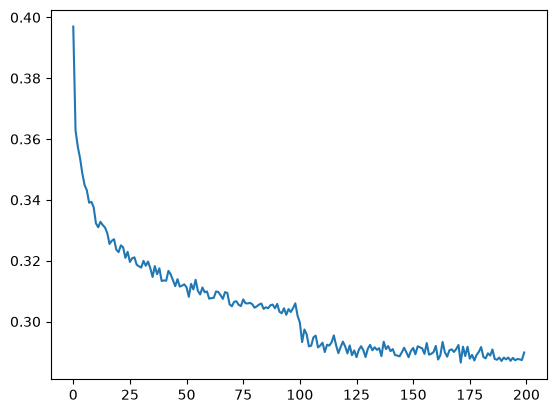

In [64]:
for layer in model.layers:
    layer.training=False
@torch.no_grad()
def split_loss(split):
    x,y = {
        'train': (Xtr, Ytr),
        'val': (Xdev, Ydev),
        'test': (Xte, Yte),
    }[split]

    logits=model(x)
    loss = F.cross_entropy(logits, y)

    print(split, loss.item())

split_loss('train')
split_loss('val')

plt.plot(torch.tensor(lossi).view(-1,1000).mean(1))

In [65]:
#轻微的提升哈哈

In [66]:
#接下来可以进一步提升我们的神经网络规模来提升性能了
n_embd=24
n_hidden=128

layers=[
    Embedding(vocab_size,n_embd),
    FlattenConsecutive(2),Linear(n_embd*2,n_hidden,bias=False),BatchNorm1d(n_hidden),Tanh(),
    FlattenConsecutive(2),Linear(n_hidden*2,n_hidden,bias=False),BatchNorm1d(n_hidden),Tanh(),
    FlattenConsecutive(2),Linear(n_hidden*2,n_hidden,bias=False),BatchNorm1d(n_hidden),Tanh(),
    Linear(n_hidden,vocab_size),
]

with torch.no_grad():
    layers[-1].weight*=0.1

model=Sequential(layers)

parameters=model.parameters()
print("总参数量：",sum(p.nelement() for p in parameters))
for p in parameters:
    p.requires_grad=True

总参数量： 76579


In [67]:
#重新训练下
max_steps=200000
batch_size=32
lossi=[]

for i in range(max_steps):

    #batch
    ix = torch.randint(0,Xtr.shape[0],(batch_size,))
    Xb,Yb=Xtr[ix],Ytr[ix]

    #前向传播
    logits=model(Xb)
    loss=F.cross_entropy(logits,Yb)

    #让每一层的out的grad保留下来
    for layer in layers:
        layer.out.retain_grad()

    #清空梯度
    for p in parameters:
        p.grad=None

    #反向传播
    loss.backward()

    #更新
    lr = 0.1 if i < max_steps/2 else 0.01
    for p in parameters:
        p.data += -lr * p.grad

    if i%10000==0:
        print(f"当前轮次:{i:7d}/总轮次:{max_steps:7d} loss={loss.item():.4f}")

    lossi.append(loss.log10().item())

当前轮次:      0/总轮次: 200000 loss=3.2984
当前轮次:  10000/总轮次: 200000 loss=2.5074
当前轮次:  20000/总轮次: 200000 loss=2.0514
当前轮次:  30000/总轮次: 200000 loss=2.0768
当前轮次:  40000/总轮次: 200000 loss=1.9987
当前轮次:  50000/总轮次: 200000 loss=1.6841
当前轮次:  60000/总轮次: 200000 loss=1.7880
当前轮次:  70000/总轮次: 200000 loss=2.0348
当前轮次:  80000/总轮次: 200000 loss=2.1625
当前轮次:  90000/总轮次: 200000 loss=2.2595
当前轮次: 100000/总轮次: 200000 loss=1.7723
当前轮次: 110000/总轮次: 200000 loss=1.6939
当前轮次: 120000/总轮次: 200000 loss=1.8657
当前轮次: 130000/总轮次: 200000 loss=1.6251
当前轮次: 140000/总轮次: 200000 loss=1.3871
当前轮次: 150000/总轮次: 200000 loss=2.0172
当前轮次: 160000/总轮次: 200000 loss=1.7628
当前轮次: 170000/总轮次: 200000 loss=1.8196
当前轮次: 180000/总轮次: 200000 loss=1.7710
当前轮次: 190000/总轮次: 200000 loss=1.6615


train 1.7868437767028809
val 2.000532388687134


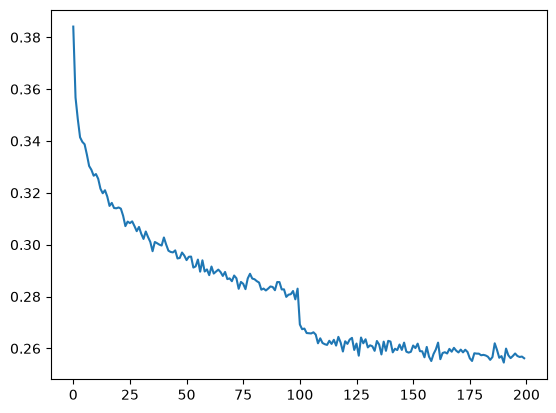

In [68]:
for layer in model.layers:
    layer.training=False
@torch.no_grad()
def split_loss(split):
    x,y = {
        'train': (Xtr, Ytr),
        'val': (Xdev, Ydev),
        'test': (Xte, Yte),
    }[split]

    logits=model(x)
    loss = F.cross_entropy(logits, y)

    print(split, loss.item())

split_loss('train')
split_loss('val')

plt.plot(torch.tensor(lossi).view(-1,1000).mean(1))

In [69]:
#哦哦哦太强了太强了，第一次在验证集的loss跌破了2 

In [70]:
#而且读者们可以发现这种方法有个非常神奇的地方：我们的模型不再在结构上被固定的 block_size 限制。
#之前我们会把emb压缩
#比如(32,3,10)压缩成(32,30)
#如果我们的上下文大小从3变成了8
#原来的模型就会出现问题
#因为压缩完了变成(32,80)
#这个80会导致矩阵乘法出问题
#但是现在我们保留这个维度，也就是block_size
#模型的参数不再依赖具体的上下文长度 T，而主要依赖 embedding 维度 C
#我们的模型从上下文大小解放出来了

In [71]:
#makemore part5就到这里
#这次读者们也可以像makemore1那样，自己调整一下模型参数来看看，loss能不能降得更低

In [72]:
n_embd=32
n_hidden=256

layers=[
    Embedding(vocab_size,n_embd),
    FlattenConsecutive(2),Linear(n_embd*2,  n_hidden,bias=False),BatchNorm1d(n_hidden),Tanh(),
    FlattenConsecutive(2),Linear(n_hidden*2,n_hidden,bias=False),BatchNorm1d(n_hidden),Tanh(),
    FlattenConsecutive(2),Linear(n_hidden*2,n_hidden,bias=False),BatchNorm1d(n_hidden),Tanh(),
    Linear(n_hidden,vocab_size),
]

with torch.no_grad():
    layers[-1].weight*=0.1

model=Sequential(layers)

parameters=model.parameters()
print("总参数量：",sum(p.nelement() for p in parameters))
for p in parameters:
    p.requires_grad=True

总参数量： 287867


In [73]:
#重新训练下
max_steps=200000
batch_size=64
lossi=[]

for i in range(max_steps):

    #batch
    ix = torch.randint(0,Xtr.shape[0],(batch_size,))
    Xb,Yb=Xtr[ix],Ytr[ix]

    #前向传播
    logits=model(Xb)
    loss=F.cross_entropy(logits,Yb)

    #让每一层的out的grad保留下来
    for layer in layers:
        layer.out.retain_grad()

    #清空梯度
    for p in parameters:
        p.grad=None

    #反向传播
    loss.backward()

    #更新
    lr = 0.1 if i < max_steps/2 else 0.01
    for p in parameters:
        p.data += -lr * p.grad

    if i%10000==0:
        print(f"当前轮次:{i:7d}/总轮次:{max_steps:7d} loss={loss.item():.4f}")

    lossi.append(loss.log10().item())

当前轮次:      0/总轮次: 200000 loss=3.2847
当前轮次:  10000/总轮次: 200000 loss=2.1662
当前轮次:  20000/总轮次: 200000 loss=1.6609
当前轮次:  30000/总轮次: 200000 loss=1.9251
当前轮次:  40000/总轮次: 200000 loss=2.0383
当前轮次:  50000/总轮次: 200000 loss=1.9486
当前轮次:  60000/总轮次: 200000 loss=1.8773
当前轮次:  70000/总轮次: 200000 loss=1.9485
当前轮次:  80000/总轮次: 200000 loss=1.5618
当前轮次:  90000/总轮次: 200000 loss=1.8160
当前轮次: 100000/总轮次: 200000 loss=1.7683
当前轮次: 110000/总轮次: 200000 loss=1.6480
当前轮次: 120000/总轮次: 200000 loss=1.4407
当前轮次: 130000/总轮次: 200000 loss=1.2709
当前轮次: 140000/总轮次: 200000 loss=1.6596
当前轮次: 150000/总轮次: 200000 loss=1.7627
当前轮次: 160000/总轮次: 200000 loss=1.3409
当前轮次: 170000/总轮次: 200000 loss=1.7976
当前轮次: 180000/总轮次: 200000 loss=1.5574
当前轮次: 190000/总轮次: 200000 loss=1.4069


train 1.5520188808441162
val 2.09391713142395


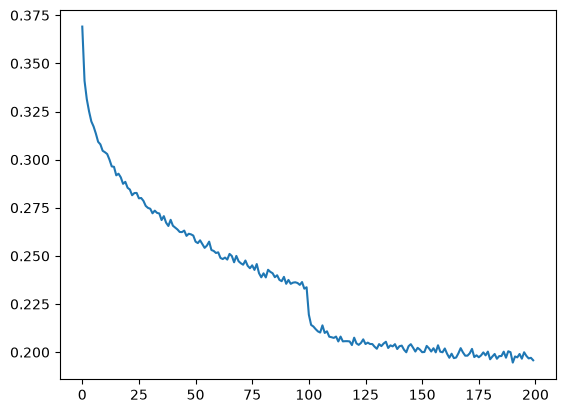

In [74]:
for layer in model.layers:
    layer.training=False
@torch.no_grad()
def split_loss(split):
    x,y = {
        'train': (Xtr, Ytr),
        'val': (Xdev, Ydev),
        'test': (Xte, Yte),
    }[split]

    logits=model(x)
    loss = F.cross_entropy(logits, y)

    print(split, loss.item())

split_loss('train')
split_loss('val')

plt.plot(torch.tensor(lossi).view(-1,1000).mean(1))

In [75]:
#啊哦，好像有过拟合了
n_embd=32
n_hidden=128

layers=[
    Embedding(vocab_size,n_embd),
    FlattenConsecutive(2),Linear(n_embd*2,  n_hidden,bias=False),BatchNorm1d(n_hidden),Tanh(),
    FlattenConsecutive(2),Linear(n_hidden*2,n_hidden,bias=False),BatchNorm1d(n_hidden),Tanh(),
    FlattenConsecutive(2),Linear(n_hidden*2,n_hidden,bias=False),BatchNorm1d(n_hidden),Tanh(),
    Linear(n_hidden,vocab_size),
]

with torch.no_grad():
    layers[-1].weight*=0.1

model=Sequential(layers)

parameters=model.parameters()
print("总参数量：",sum(p.nelement() for p in parameters))
for p in parameters:
    p.requires_grad=True

总参数量： 78843


In [76]:
#重新训练下
max_steps=200000
batch_size=48
lossi=[]

for i in range(max_steps):

    #batch
    ix = torch.randint(0,Xtr.shape[0],(batch_size,))
    Xb,Yb=Xtr[ix],Ytr[ix]

    #前向传播
    logits=model(Xb)
    loss=F.cross_entropy(logits,Yb)

    #让每一层的out的grad保留下来
    for layer in layers:
        layer.out.retain_grad()

    #清空梯度
    for p in parameters:
        p.grad=None

    #反向传播
    loss.backward()

    #更新
    lr = 0.1 if i < max_steps/2 else 0.01
    for p in parameters:
        p.data += -lr * p.grad

    if i%10000==0:
        print(f"当前轮次:{i:7d}/总轮次:{max_steps:7d} loss={loss.item():.4f}")

    lossi.append(loss.log10().item())

当前轮次:      0/总轮次: 200000 loss=3.2955
当前轮次:  10000/总轮次: 200000 loss=2.0558
当前轮次:  20000/总轮次: 200000 loss=2.3982
当前轮次:  30000/总轮次: 200000 loss=1.8221
当前轮次:  40000/总轮次: 200000 loss=1.8147
当前轮次:  50000/总轮次: 200000 loss=1.6857
当前轮次:  60000/总轮次: 200000 loss=1.8540
当前轮次:  70000/总轮次: 200000 loss=1.7469
当前轮次:  80000/总轮次: 200000 loss=1.6132
当前轮次:  90000/总轮次: 200000 loss=1.7105
当前轮次: 100000/总轮次: 200000 loss=1.9974
当前轮次: 110000/总轮次: 200000 loss=1.9057
当前轮次: 120000/总轮次: 200000 loss=1.6312
当前轮次: 130000/总轮次: 200000 loss=1.9319
当前轮次: 140000/总轮次: 200000 loss=1.8803
当前轮次: 150000/总轮次: 200000 loss=1.7284
当前轮次: 160000/总轮次: 200000 loss=1.7509
当前轮次: 170000/总轮次: 200000 loss=1.6991
当前轮次: 180000/总轮次: 200000 loss=1.6733
当前轮次: 190000/总轮次: 200000 loss=1.5223


train 1.7253109216690063
val 2.008479356765747


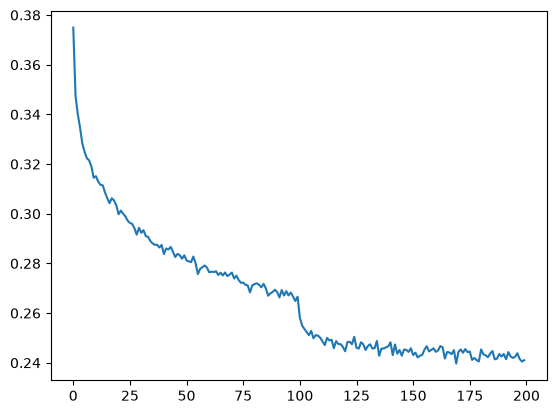

In [77]:
for layer in model.layers:
    layer.training=False
@torch.no_grad()
def split_loss(split):
    x,y = {
        'train': (Xtr, Ytr),
        'val': (Xdev, Ydev),
        'test': (Xte, Yte),
    }[split]

    logits=model(x)
    loss = F.cross_entropy(logits, y)

    print(split, loss.item())

split_loss('train')
split_loss('val')

plt.plot(torch.tensor(lossi).view(-1,1000).mean(1))

总参数量： 76579
当前轮次:      0/总轮次: 200000 loss=3.3024
当前轮次:  10000/总轮次: 200000 loss=1.9187
当前轮次:  20000/总轮次: 200000 loss=1.9218
当前轮次:  30000/总轮次: 200000 loss=1.6844
当前轮次:  40000/总轮次: 200000 loss=2.1128
当前轮次:  50000/总轮次: 200000 loss=2.1278
当前轮次:  60000/总轮次: 200000 loss=1.9742
当前轮次:  70000/总轮次: 200000 loss=1.8423
当前轮次:  80000/总轮次: 200000 loss=2.0212
当前轮次:  90000/总轮次: 200000 loss=2.0511
当前轮次: 100000/总轮次: 200000 loss=2.1444
当前轮次: 110000/总轮次: 200000 loss=1.8969
当前轮次: 120000/总轮次: 200000 loss=2.0924
当前轮次: 130000/总轮次: 200000 loss=2.1939
当前轮次: 140000/总轮次: 200000 loss=1.4493
当前轮次: 150000/总轮次: 200000 loss=2.1461
当前轮次: 160000/总轮次: 200000 loss=1.7313
当前轮次: 170000/总轮次: 200000 loss=1.9921
当前轮次: 180000/总轮次: 200000 loss=1.9348
当前轮次: 190000/总轮次: 200000 loss=1.5916
train 1.7818350791931152
val 1.9933509826660156


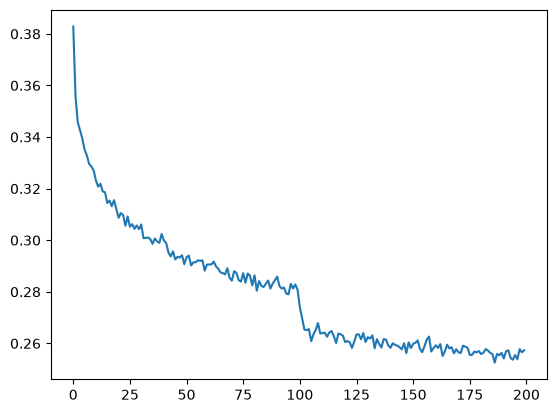

In [78]:
#好像还是之前的好哈哈哈
n_embd=24
n_hidden=128

layers=[
    Embedding(vocab_size,n_embd),
    FlattenConsecutive(2),Linear(n_embd*2,  n_hidden,bias=False),BatchNorm1d(n_hidden),Tanh(),
    FlattenConsecutive(2),Linear(n_hidden*2,n_hidden,bias=False),BatchNorm1d(n_hidden),Tanh(),
    FlattenConsecutive(2),Linear(n_hidden*2,n_hidden,bias=False),BatchNorm1d(n_hidden),Tanh(),
    Linear(n_hidden,vocab_size),
]

with torch.no_grad():
    layers[-1].weight*=0.1

model=Sequential(layers)

parameters=model.parameters()
print("总参数量：",sum(p.nelement() for p in parameters))
for p in parameters:
    p.requires_grad=True

#重新训练下
max_steps=200000
batch_size=32
lossi=[]

for i in range(max_steps):

    #batch
    ix = torch.randint(0,Xtr.shape[0],(batch_size,))
    Xb,Yb=Xtr[ix],Ytr[ix]

    #前向传播
    logits=model(Xb)
    loss=F.cross_entropy(logits,Yb)

    #让每一层的out的grad保留下来
    for layer in layers:
        layer.out.retain_grad()

    #清空梯度
    for p in parameters:
        p.grad=None

    #反向传播
    loss.backward()

    #更新
    lr = 0.1 if i < max_steps/2 else 0.01
    for p in parameters:
        p.data += -lr * p.grad

    if i%10000==0:
        print(f"当前轮次:{i:7d}/总轮次:{max_steps:7d} loss={loss.item():.4f}")

    lossi.append(loss.log10().item())

for layer in model.layers:
    layer.training=False
@torch.no_grad()
def split_loss(split):
    x,y = {
        'train': (Xtr, Ytr),
        'val': (Xdev, Ydev),
        'test': (Xte, Yte),
    }[split]

    logits=model(x)
    loss = F.cross_entropy(logits, y)

    print(split, loss.item())

split_loss('train')
split_loss('val')

plt.plot(torch.tensor(lossi).view(-1,1000).mean(1))

In [79]:
#生成一下
for i in range(20):
    context = [0] * block_size
    out = []
    while True:
        logits=model(torch.tensor([context]))
        probs = F.softmax(logits, dim=1)
        ix = torch.multinomial(
            probs,
            num_samples=1
        ).item()
        context = context[1:] + [ix]
        out.append(itos[ix])
        if ix == 0:
            break

    print(''.join(out))

zetyre.
alizen.
sesan.
arahni.
sema.
atlairabel.
wylder.
jexd.
berliton.
averlett.
houston.
caisley.
katon.
leanna.
mashnaurabell.
sahaq.
suzen.
aanjaha.
rodrick.
zamiya.


In [80]:
#明显现在绝大部分都可以作为真实姓名使用了
#makemore part5完结撒花！